# 02 - The experimental progression
Physics baseline → EDA → linear/polynomial → K-Means regimes → trees → random forest → XGBoost/LightGBM → feature engineering/tuning → neural network → explainability → physics-structured/hybrid → selection → anomalies → optimisation.
Narrative (why / expected / happened / learned / next) for each step: `experiments/LOG.md`. Expectations were frozen in `experiments/PROTOCOL.md` before the runs.

Columns: `v*` = validation (all windows), `ood_MAE` = extrapolation band, engaged windows.

In [1]:
import sys, json, warnings
from pathlib import Path
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
from IPython.display import Image, display, Markdown
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30); pd.set_option("display.max_colwidth", 60)
FIG, TAB, RES = ROOT/"results/figures", ROOT/"results/tables", ROOT/"experiments/results"
def show(name, width=760): display(Image(filename=str(FIG/name), width=width))

In [2]:
df = pd.read_csv(TAB/'all_experiments_long.csv')
syn = df[df.dataset == 'synthetic'].copy()
def table(prefixes):
    t = syn[syn.exp_id.str.startswith(tuple(prefixes))][['exp_id','model','train.all.mae','val.all.mae','val.all.rmse','val.all.r2','val.all.mape','ood_val.engaged.mae']]
    t.columns = ['exp','model','train_MAE','val_MAE','val_RMSE','val_R2','val_MAPE','ood_MAE']
    return t.round(3).reset_index(drop=True)

## E00 physics baselines, E02 linear/polynomial

In [3]:
table(['E00','E02'])

,exp,model,train_MAE,val_MAE,val_RMSE,val_R2,val_MAPE,ood_MAE
0,E00a,mean,2.760,2.895,4.097,-0.000,42.018,11.011
1,E00b,sec_P0+k*MRR_fitted,1.737,1.775,2.462,0.639,26.512,3.792
2,E00c,handbook_physics_zero_fit,1.798,1.809,2.430,0.648,18.715,4.796
3,E02a,ridge_linear,1.398,1.492,2.194,0.713,17.407,5.593
4,E02b,ridge_poly2,0.678,0.705,1.398,0.884,7.213,2.496
5,E02c,ridge_poly3,0.509,0.607,1.305,0.899,6.150,2.208


## E03 K-Means regimes
Silhouette does not pick the physical k=4; clusters are speed bands, not machine states (standby and rapid are recovered perfectly).

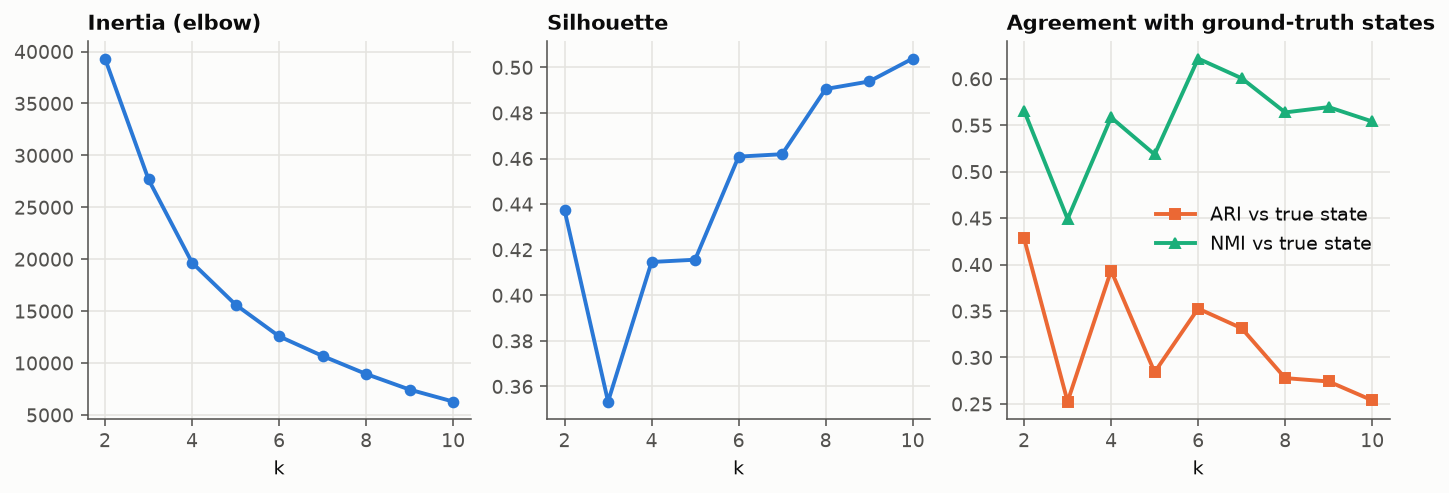

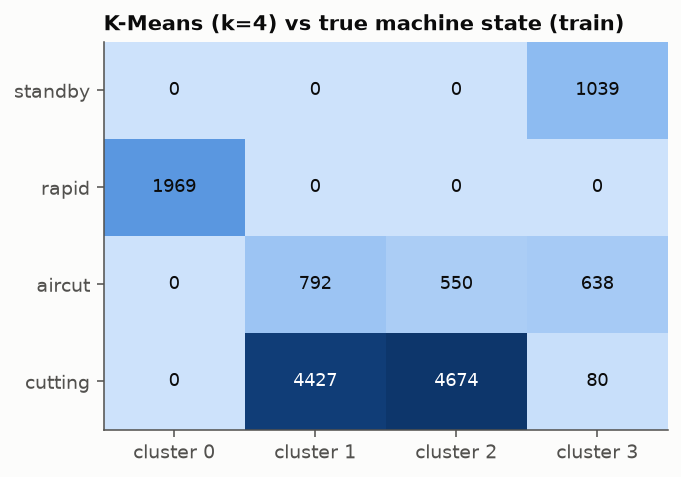

In [4]:
show('e03_kmeans_selection_synthetic.png', 900); show('e03_confusion_k4_synthetic.png', 520)

In [5]:
table(['E03'])

,exp,model,train_MAE,val_MAE,val_RMSE,val_R2,val_MAPE,ood_MAE
0,E03b,ridge_linear__global,1.398,1.492,2.194,0.713,17.413,5.591
1,E03c,ridge_linear__kmeans4_onehot,1.335,1.411,2.116,0.733,15.965,5.397
2,E03c,ridge_linear__kmeans4_per_cluster,1.114,1.166,1.949,0.774,11.367,4.691
3,E03c,ridge_linear__kmeans10_onehot,1.264,1.375,2.073,0.744,15.561,5.025
4,E03c,ridge_linear__kmeans10_per_cluster,0.857,0.904,1.714,0.825,8.270,3.773
5,E03b,ridge_poly2__global,0.677,0.704,1.399,0.883,7.201,2.516
6,E03c,ridge_poly2__kmeans4_onehot,0.648,0.682,1.375,0.887,6.940,2.385
7,E03c,ridge_poly2__kmeans4_per_cluster,0.594,0.689,1.393,0.884,6.798,2.236
8,E03c,ridge_poly2__kmeans10_onehot,0.595,0.645,1.335,0.894,6.485,2.185
9,E03c,ridge_poly2__kmeans10_per_cluster,0.514,0.771,1.596,0.848,7.944,2.317


## E04-E06 trees, forest, boosting

In [6]:
table(['E04','E05','E06'])

,exp,model,train_MAE,val_MAE,val_RMSE,val_R2,val_MAPE,ood_MAE
0,E04a,decision_tree_unconstrained,0.000,1.274,2.550,0.613,12.011,4.071
1,E04b,decision_tree_tuned,0.712,1.033,1.888,0.788,9.678,3.534
2,E05a,random_forest_default,0.113,0.855,1.625,0.843,8.102,3.221
3,E05b,random_forest_tuned,0.137,0.833,1.575,0.852,7.912,3.528
4,E06a,xgboost_default,0.225,0.861,1.608,0.846,8.475,2.969
5,E06b,xgboost_tuned,0.326,0.672,1.387,0.885,6.394,2.831
6,E06c,lightgbm_default,0.340,0.692,1.413,0.881,6.477,2.832
7,E06d,lightgbm_tuned,0.440,0.665,1.380,0.887,6.359,2.978
8,E06e,lightgbm_tuned_huber_loss,0.694,0.842,1.844,0.797,6.994,5.949
9,E06e,lightgbm_tuned_l1_loss,0.493,0.683,1.545,0.858,5.829,4.102


## E07 feature engineering (bigger gain than tuning)

In [7]:
table(['E07'])

,exp,model,train_MAE,val_MAE,val_RMSE,val_R2,val_MAPE,ood_MAE
0,E07a,ridge_linear__generic_fe,0.928,1.009,1.666,0.835,11.766,3.098
1,E07a,ridge_poly2__generic_fe,0.495,0.514,1.229,0.910,5.046,2.079
2,E07b,random_forest_tuned_params__generic_fe,0.138,0.676,1.443,0.876,6.393,2.522
3,E07c,lightgbm_default__generic_fe,0.314,0.584,1.329,0.895,5.450,2.205
4,E07c,lightgbm_tuned_params__generic_fe,0.391,0.555,1.275,0.903,5.231,2.166
5,E07a,ridge_linear__physics_fe,0.568,0.562,1.238,0.909,5.921,2.065
6,E07a,ridge_poly2__physics_fe,0.449,0.462,1.157,0.920,4.563,1.613
7,E07b,random_forest_tuned_params__physics_fe,0.139,0.578,1.288,0.901,5.593,2.012
8,E07c,lightgbm_default__physics_fe,0.303,0.515,1.214,0.912,4.910,2.052
9,E07c,lightgbm_tuned_params__physics_fe,0.365,0.481,1.178,0.917,4.585,1.894


## E08 neural network (5 seeds; std over seeds shown for the single networks)

In [8]:
t = table(['E08'])
t['val_MAE_seed_std'] = syn[syn.exp_id.str.startswith('E08')]['val.all.mae_std_over_seeds'].round(3).to_numpy()
t

,exp,model,train_MAE,val_MAE,val_RMSE,val_R2,val_MAPE,ood_MAE,val_MAE_seed_std
0,E08b,mlp_commanded,0.521,0.616,1.349,0.892,6.031,2.464,0.022
1,E08c,mlp_commanded_ensemble5,0.466,0.559,1.311,0.898,5.291,2.365,NaN
2,E08b,mlp_physics_fe,0.467,0.485,1.176,0.918,4.814,1.626,0.025
3,E08c,mlp_physics_fe_ensemble5,0.433,0.449,1.158,0.920,4.298,1.590,NaN


## E09 explainability

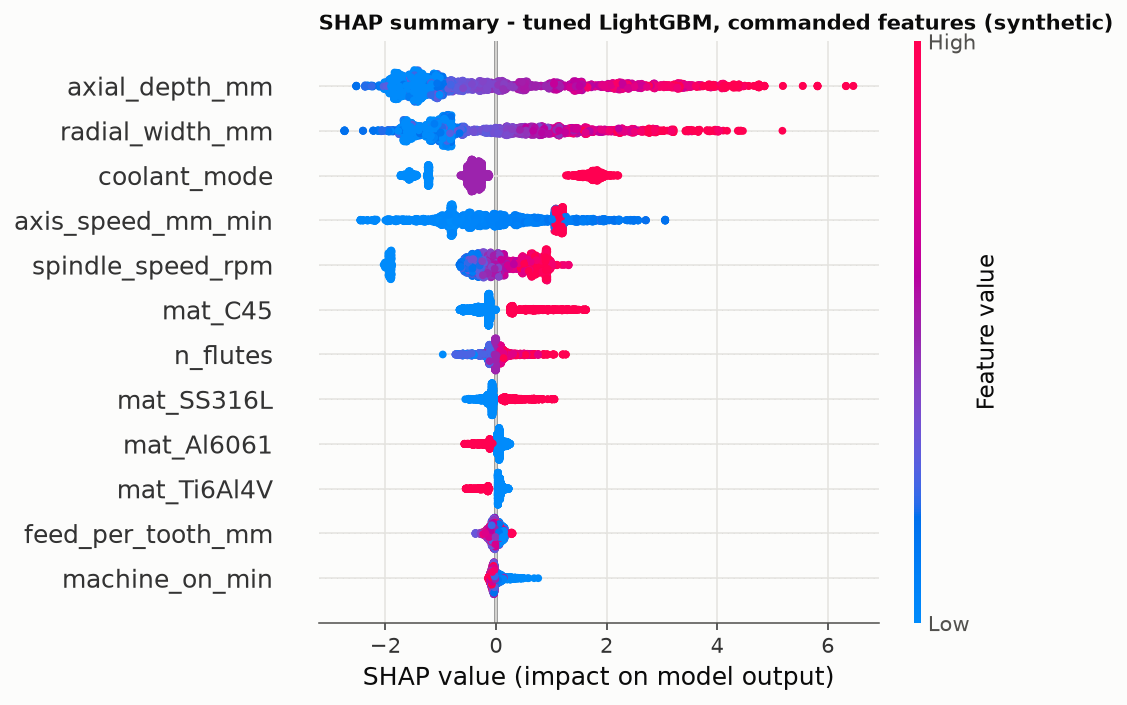

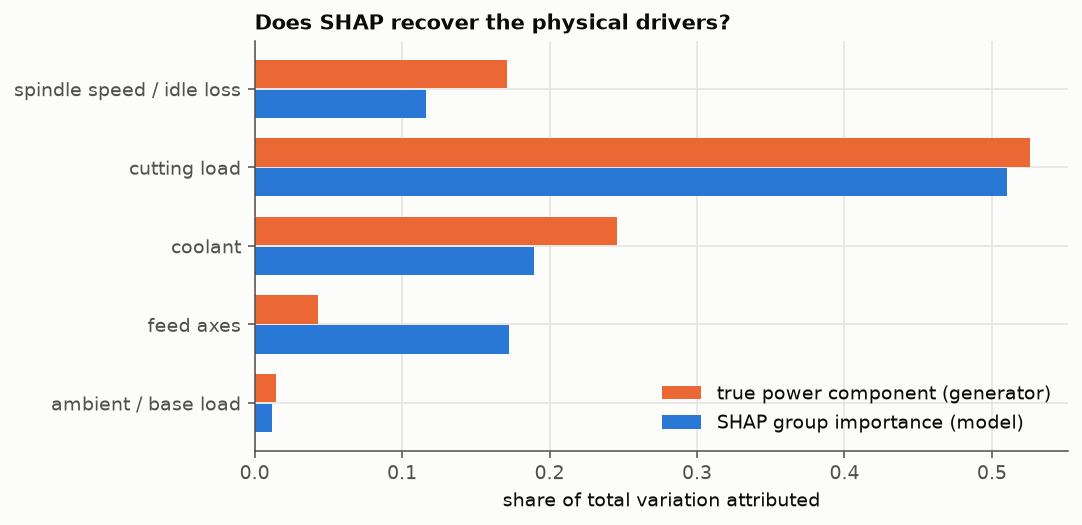

In [9]:
show('e09_shap_beeswarm_synthetic.png', 720); show('e09_shap_vs_truth_groups.png', 720)

In [10]:
pd.read_csv(TAB/'e09_shap_groups_vs_truth.csv', index_col=0)

,shap_mean_abs_kw,true_component_mean_abs_dev_kw,shap_share,true_share
spindle speed / idle loss,0.5390,0.8214,0.1161,0.1712
cutting load,2.3668,2.5216,0.5099,0.5255
coolant,0.8795,1.1790,0.1895,0.2457
feed axes,0.8007,0.2072,0.1725,0.0432
ambient / base load,0.0556,0.0688,0.0120,0.0143


## E10 physics-structured and hybrid models

In [11]:
table(['E10'])

,exp,model,train_MAE,val_MAE,val_RMSE,val_R2,val_MAPE,ood_MAE
0,E10a,physics_parametric_fitted,0.394,0.377,1.161,0.920,3.201,1.434
1,E10b,physics_parametric_fitted_squared_loss,0.437,0.413,1.140,0.923,3.816,1.465
2,E10c,hybrid_physics+lgbm_residual,0.410,0.419,1.149,0.921,3.940,1.482
3,E10d,hybrid_lgbm_with_physics_feature,0.350,0.458,1.190,0.916,4.252,1.779


In [12]:
pd.read_csv(TAB/'e10_param_recovery.csv').round(4)

,parameter,fitted,generator_truth_(effective),rel_error_%
0,p0 (base + servo) [kW],2.6117,2.6000,0.5
1,ambient coeff [kW/degC],0.0213,0.0200,6.6
2,flood coolant [kW],1.5324,1.5000,2.2
3,high-pressure coolant [kW],4.2214,4.2000,0.5
4,chip conveyor [kW],0.3880,0.3500,10.8
5,idle loss l0 [kW],0.2030,0.1865,8.8
6,idle loss l1 [kW/rpm],0.0002,0.0002,-7.6
7,idle loss l2 [kW/rpm^2],0.0000,0.0000,14.3
8,warm-up amplitude,0.3282,0.3000,9.4
9,warm-up tau [min],37.7898,40.0000,-5.5


## E11 selection by the frozen rule
`score = 0.5·MAE_val/min + 0.5·MAE_oodval_engaged/min`, ties within 2 % go to the simpler model.

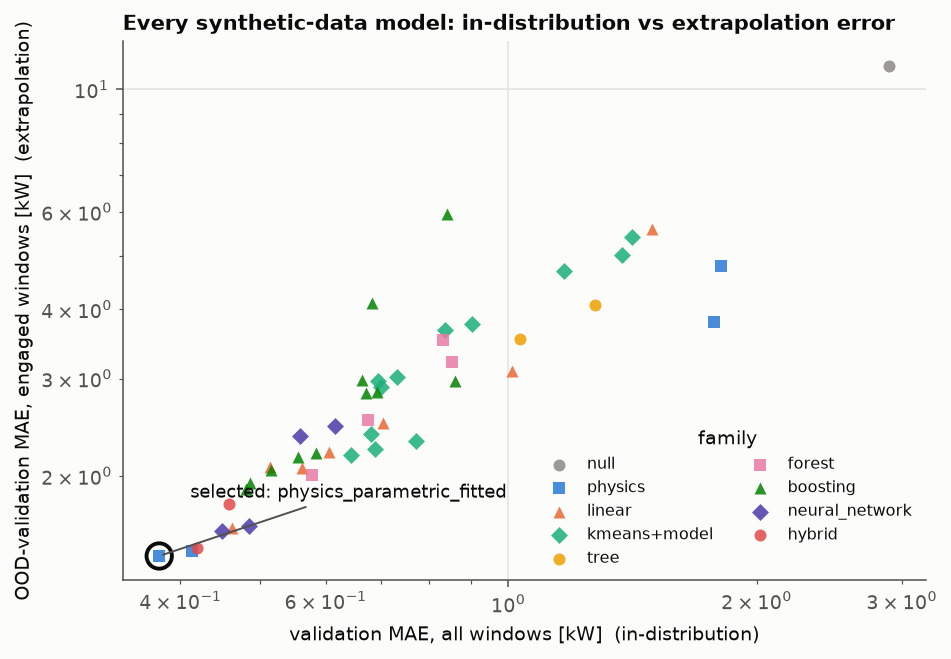

In [13]:
show('e11_model_landscape.png', 760)

In [14]:
lb = pd.read_csv(TAB/'leaderboard_synthetic.csv')
lb[['model','family','complexity','val_mae','oodval_eng_mae','score']].head(12).round(3)

,model,family,complexity,val_mae,oodval_eng_mae,score
0,physics_parametric_fitted,physics,3,0.377,1.434,1.000
1,physics_parametric_fitted_squared_loss,physics,3,0.413,1.465,1.058
2,hybrid_physics+lgbm_residual,hybrid,7,0.419,1.482,1.072
3,mlp_physics_fe_ensemble5,neural_network,8,0.449,1.590,1.150
4,ridge_poly2__physics_fe,linear,3,0.462,1.613,1.175
5,mlp_physics_fe,neural_network,8,0.485,1.626,1.209
6,hybrid_lgbm_with_physics_feature,hybrid,7,0.458,1.779,1.227
7,lightgbm_tuned_params__physics_fe,boosting,6,0.481,1.894,1.298
8,lightgbm_retuned__physics_fe,boosting,6,0.486,1.947,1.322
9,lightgbm_default__physics_fe,boosting,6,0.515,2.052,1.398


In [15]:
sel = json.load(open(RES/'E11_selection.json'))
print('WINNER:', sel['winner'], '| within 2% of best:', sel['candidates_within_2pct'])
pd.DataFrame({sp: {sub: m for sub, m in d.items()} for sp, d in sel['final_metrics_trainval_refit'].items()}).map(lambda m: {k: round(v, 3) for k, v in m.items()})

WINNER: physics_parametric_fitted | within 2% of best: ['physics_parametric_fitted']


,test,ood_test
all,"{'mae': 0.365, 'rmse': 1.01, 'r2': 0.931, 'mape': 3.289,...","{'mae': 0.95, 'rmse': 1.984, 'r2': 0.917, 'mape': 5.57, ..."
engaged,"{'mae': 0.451, 'rmse': 1.099, 'r2': 0.911, 'mape': 3.637...","{'mae': 1.292, 'rmse': 2.327, 'r2': 0.667, 'mape': 6.648..."
nominal_rows,"{'mae': 0.322, 'rmse': 0.681, 'r2': 0.967, 'mape': 3.064...","{'mae': 0.875, 'rmse': 1.335, 'r2': 0.961, 'mape': 5.361..."


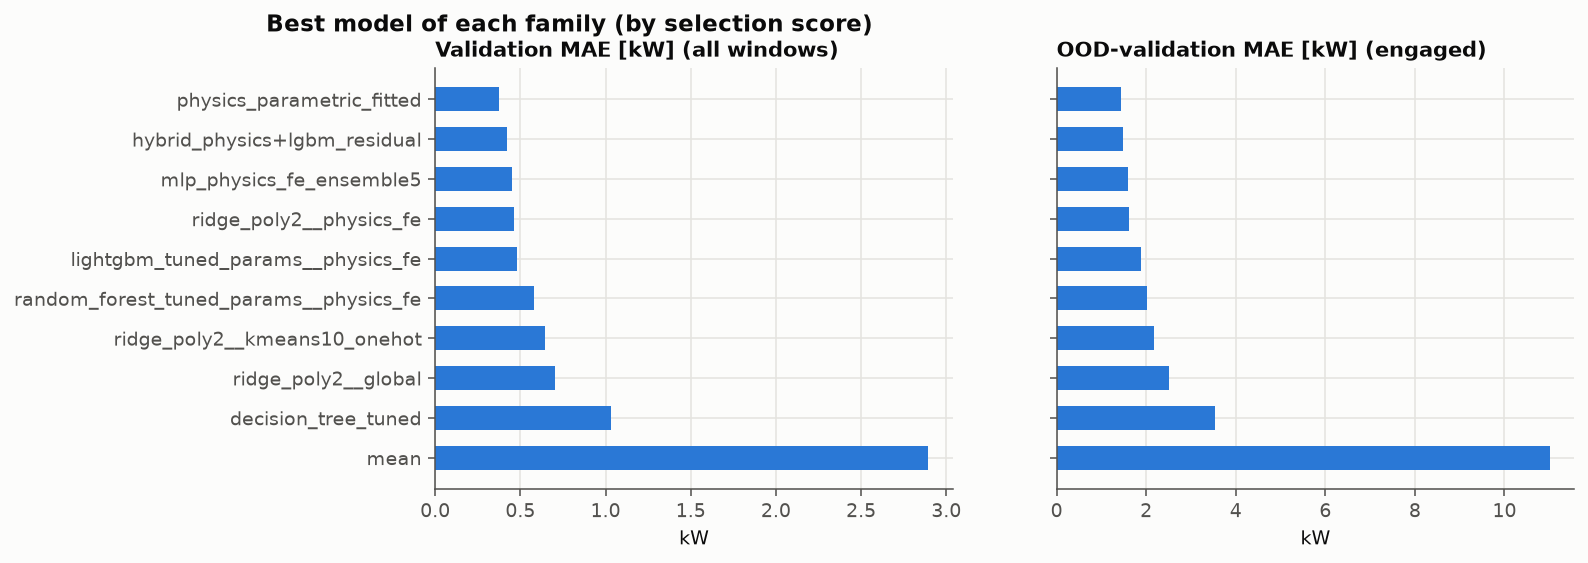

In [16]:
show('e11_family_best.png', 900)

## Real-data track (supporting; see E14 for why these scores are not generalisation evidence)

In [17]:
for k in ['ibarmia', 'gmtk']:
    print('==', k); display(pd.read_csv(TAB/f'leaderboard_real_{k}.csv').round(3).head(8))

== ibarmia


,exp_id,model,family,val.all.mae,val.all.rmse,val.all.r2,val.all.mape,test.all.mae,test.all.rmse,test.all.r2,test.all.mape
0,E07c,lightgbm_tuned_params__real_fe,boosting,0.496,1.125,0.745,34.452,0.436,0.851,0.811,31.498
1,E07b,random_forest_tuned_params__real_fe,forest,0.503,1.121,0.747,33.805,0.455,0.850,0.812,32.761
2,E06d,lightgbm_tuned,boosting,0.505,1.128,0.744,34.508,0.463,0.914,0.782,33.918
3,E05a,random_forest_default,forest,0.515,1.132,0.742,34.665,0.465,0.879,0.798,33.281
4,E05b,random_forest_tuned,forest,0.521,1.123,0.746,35.215,0.471,0.875,0.800,33.779
5,E06e,lightgbm_tuned_huber_loss,boosting,0.533,1.413,0.598,30.904,0.481,1.128,0.668,29.234
6,E06b,xgboost_tuned,boosting,0.541,1.045,0.780,39.501,0.488,0.827,0.822,36.706
7,E04a,decision_tree_unconstrained,tree,0.545,1.471,0.564,38.354,0.457,1.170,0.643,33.295


== gmtk


,exp_id,model,family,val.all.mae,val.all.rmse,val.all.r2,val.all.mape,test.all.mae,test.all.rmse,test.all.r2,test.all.mape
0,E07b,random_forest_tuned_params__real_fe,forest,0.221,0.837,0.814,24.264,0.250,1.035,0.677,27.810
1,E05b,random_forest_tuned,forest,0.224,0.842,0.812,23.242,0.246,1.043,0.673,27.441
2,E05a,random_forest_default,forest,0.233,0.933,0.769,24.684,0.244,1.030,0.681,28.093
3,E04b,decision_tree_tuned,tree,0.233,0.973,0.749,26.687,0.263,1.232,0.544,30.556
4,E06e,lightgbm_tuned_huber_loss,boosting,0.236,0.975,0.748,24.704,0.266,1.167,0.590,26.536
5,E07c,lightgbm_tuned_params__real_fe,boosting,0.237,0.870,0.799,27.965,0.269,1.084,0.647,31.072
6,E08c,mlp_fe_ensemble5,neural_network,0.256,0.875,0.797,27.410,0.257,1.032,0.679,28.411
7,E04a,decision_tree_unconstrained,tree,0.256,1.189,0.626,28.761,0.267,1.243,0.535,30.607
